In [104]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import scipy as sp
from si_prefix import si_format as num2eng
import types

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [112]:
STEP_RESPONSE = r"tran_freq_step_ss_ff_tt.csv"

time_ss, freq_ss, time_tt, freq_tt, time_ff, freq_ff = np.genfromtxt(
    STEP_RESPONSE,
    delimiter=",",
    skip_header=1,
    unpack=True,
)

valid_ss = ~np.isnan(time_ss) & ~np.isnan(freq_ss)
time_ss, freq_ss = time_ss[valid_ss], freq_ss[valid_ss]

valid_tt = ~np.isnan(time_tt) & ~np.isnan(freq_tt)
time_tt, freq_tt = time_tt[valid_tt], freq_tt[valid_tt]

valid_ff = ~np.isnan(time_ff) & ~np.isnan(freq_ff)
time_ff, freq_ff = time_ff[valid_ff], freq_ff[valid_ff]

STEP_RESPONSE_DIV = r"tran_freqdiv_step_ss_tt_ff.csv"

time_div_ss, freq_div_ss, time_div_tt, freq_div_tt, time_div_ff, freq_div_ff = np.genfromtxt(
    STEP_RESPONSE_DIV,
    delimiter=",",
    skip_header=1,
    unpack=True,
)

valid_ss = ~np.isnan(time_div_ss) & ~np.isnan(freq_div_ss)
time_div_ss, freq_div_ss = time_div_ss[valid_ss], freq_div_ss[valid_ss]

valid_tt = ~np.isnan(time_div_tt) & ~np.isnan(freq_div_tt)
time_div_tt, freq_div_tt = time_div_tt[valid_tt], freq_div_tt[valid_tt]

valid_ff = ~np.isnan(time_div_ff) & ~np.isnan(freq_div_ff)
time_div_ff, freq_div_ff = time_div_ff[valid_ff], freq_div_ff[valid_ff]


STEP_RESPONSE_VCTRL = r"tran_vctrl_step_ss_tt_ff.csv"

time_vtrl_ss, vtrl_ss, time_vtrl_tt, vtrl_tt, time_vtrl_ff, vtrl_ff, = np.genfromtxt(
    STEP_RESPONSE_VCTRL,
    delimiter=",",
    skip_header=1,
    unpack=True,
)

valid_ss = ~np.isnan(time_vtrl_ss) & ~np.isnan(vtrl_ss)
time_vtrl_ss, vtrl_ss = time_vtrl_ss[valid_ss], vtrl_ss[valid_ss]

valid_tt = ~np.isnan(time_vtrl_tt) & ~np.isnan(vtrl_tt)
time_vtrl_tt, vtrl_tt = time_vtrl_tt[valid_tt], vtrl_tt[valid_tt]

valid_ff = ~np.isnan(time_vtrl_ff) & ~np.isnan(vtrl_ff)
time_vtrl_ff, vtrl_ff = time_vtrl_ff[valid_ff], vtrl_ff[valid_ff]


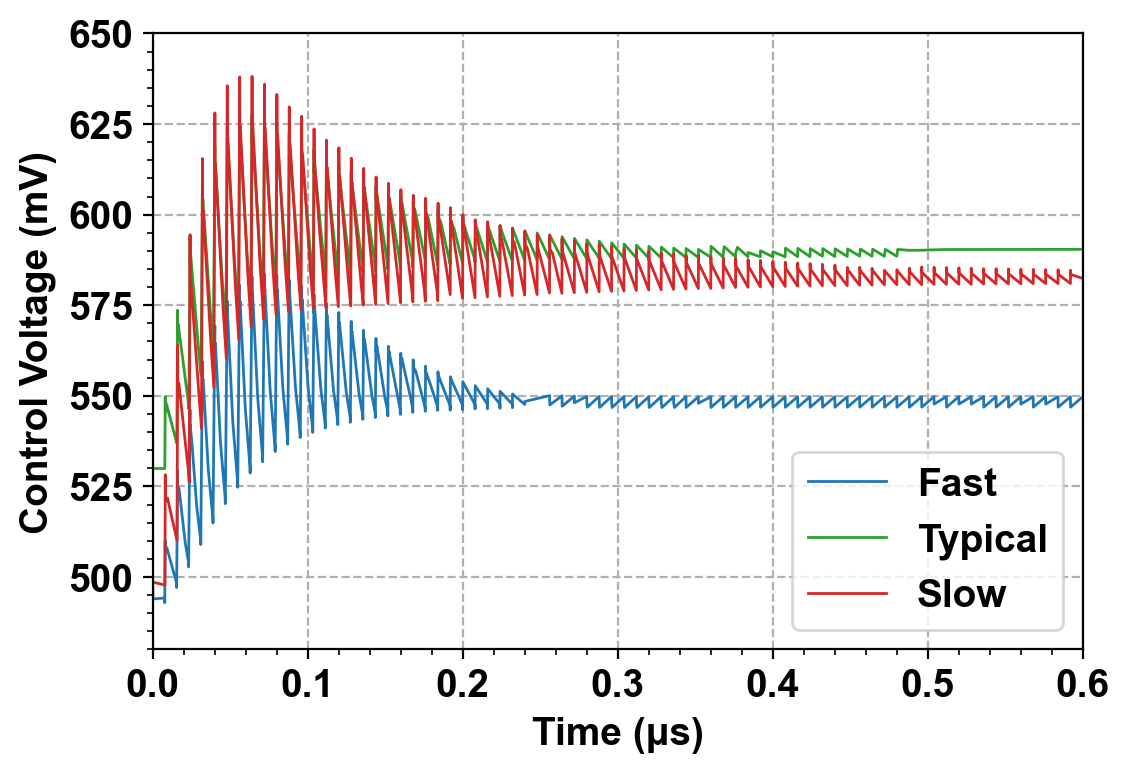

In [131]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

# Plot Step response Normalized Frequency output
plt.figure(figsize=(6, 4), dpi=200)
plt.minorticks_on()
plt.plot((time_vtrl_ff * 1e6)-1, vtrl_ff * 1e3, color='tab:blue', linewidth=1, label='Fast')
plt.plot((time_vtrl_tt * 1e6)-1, vtrl_tt * 1e3, color='tab:green', linewidth=1, label='Typical')
plt.plot((time_vtrl_ss * 1e6)-1, vtrl_ss * 1e3, color='tab:red', linewidth=1, label='Slow')
#plt.title('Step Response')
plt.xlabel('Time (μs)', fontweight='bold')
plt.ylabel('Control Voltage (mV)', fontweight='bold')
plt.grid(True, linestyle='--', which='major')
plt.xlim([0, 0.6])  # Focus on settling time region
plt.ylim([480, 650])  # Focus on settling time region
plt.legend(loc='lower right')
plt.show()



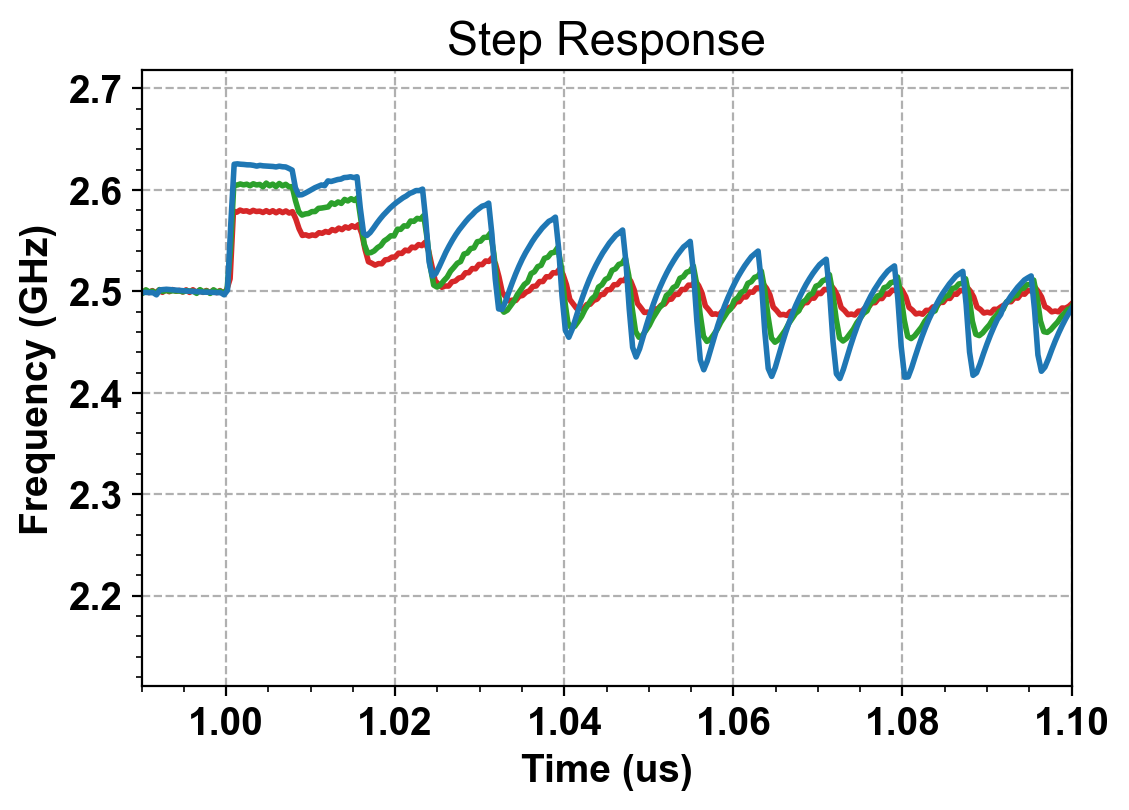

SS settling time after rising edge: 1.992 us (absolute time: 2.992 us)
TT: no settling within the pulse interval
FF: no settling within the pulse interval


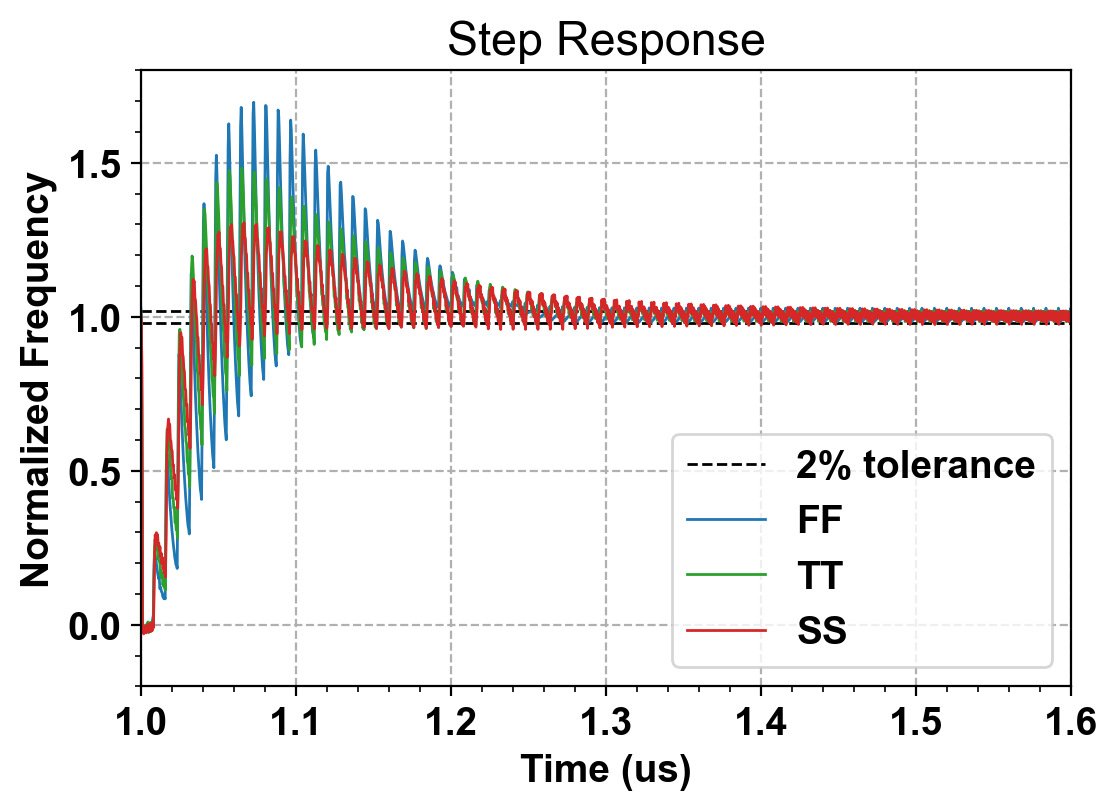

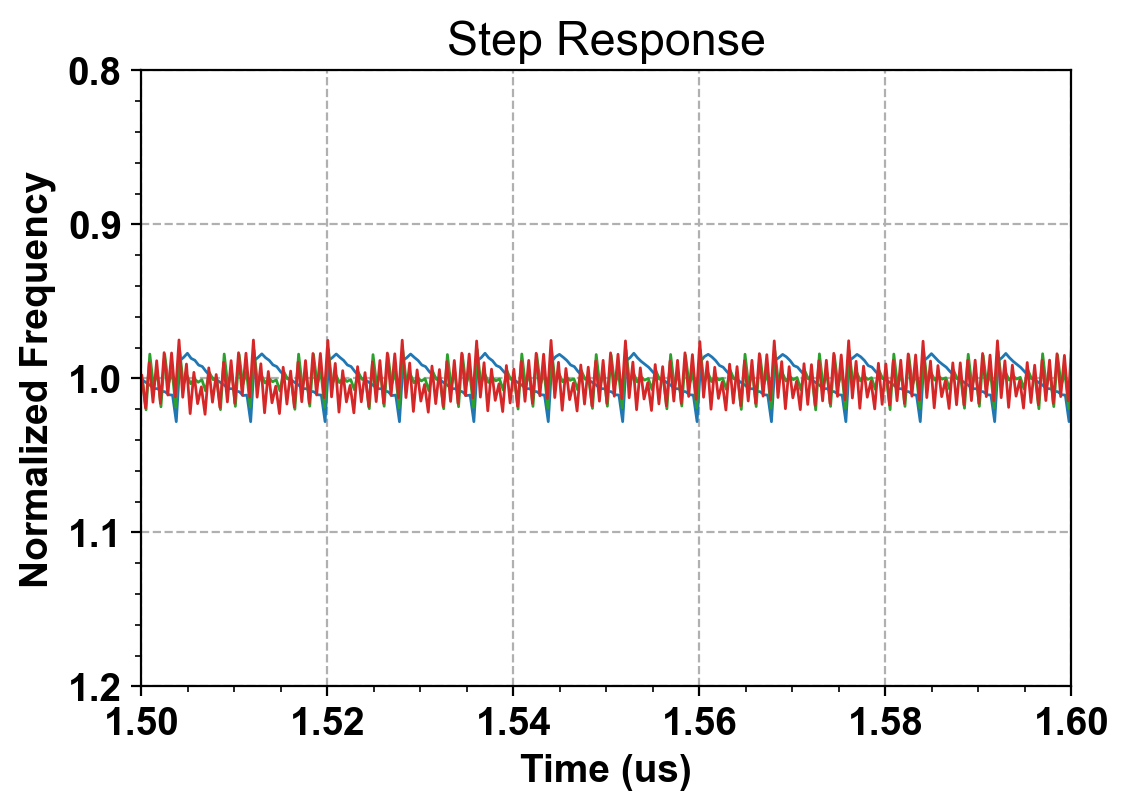

In [106]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

# Plot Step response Frequency output
plt.figure(figsize=(6, 4), dpi=200)
plt.minorticks_on()
plt.plot(time_ss * 1e6, freq_ss*1e-9, color='tab:red', linewidth=2)
plt.plot(time_tt * 1e6, freq_tt*1e-9, color='tab:green', linewidth=2)
plt.plot(time_ff * 1e6, freq_ff*1e-9, color='tab:blue', linewidth=2)
plt.title('Step Response')
plt.xlabel('Time (us)', fontweight='bold')
plt.ylabel('Frequency (GHz)', fontweight='bold')
plt.grid(True, linestyle='--', which='major')
plt.xlim([0.99, 1.1])  # Focus on settling time region
plt.show()

index_ss = np.flatnonzero(time_ss > 1.005e-6)
index_ss = index_ss[0] if index_ss.size else None

index_tt = np.flatnonzero(time_tt > 1.005e-6)
index_tt = index_tt[0] if index_tt.size else None

index_ff = np.flatnonzero(time_ff > 1.005e-6)
index_ff = index_ff[0] if index_ff.size else None

#print(num2eng(index_tt,4))
#print(num2eng(time_ss[index_tt]))
#print(num2eng(freq_ss[index_tt],4))

freq_min_ss = freq_ss[index_ss]
freq_target_ss = 2.5e9 - freq_min_ss
norm_freq_ss =(freq_ss - freq_min_ss) / freq_target_ss

freq_min_tt = freq_tt[index_tt]
freq_target_tt = 2.5e9 - freq_min_tt
norm_freq_tt =(freq_tt - freq_min_tt) / freq_target_tt

freq_min_ff = freq_ff[index_ff]
freq_target_ff = 2.5e9 - freq_min_ff
norm_freq_ff =(freq_ff - freq_min_ff) / freq_target_ff

def settling_time_2pct(time, response, step_time=1e-6, end_time=None):
    in_pulse = time >= step_time
    if end_time is not None:
        in_pulse &= time < end_time
    pulse_time = time[in_pulse]
    pulse_response = response[in_pulse]
    if not pulse_time.size:
        return None
    in_tolerance = np.isfinite(pulse_response) & (np.abs(pulse_response - 1.0) <= 0.02)
    remains_in_tolerance = np.logical_and.accumulate(in_tolerance[::-1])[::-1]
    candidates = np.flatnonzero(remains_in_tolerance)
    if not candidates.size:
        return None
    return pulse_time[candidates[0]] - step_time

settling_ss = settling_time_2pct(time_ss, norm_freq_ss, end_time=3e-6)
settling_tt = settling_time_2pct(time_tt, norm_freq_tt, end_time=3e-6)
settling_ff = settling_time_2pct(time_ff, norm_freq_ff, end_time=3e-6)

for label, settling_time in (
    ('SS', settling_ss),
    ('TT', settling_tt),
    ('FF', settling_ff),
):
    if settling_time is None:
        print(f'{label}: no settling within the pulse interval')
    else:
        absolute_time = 1e-6 + settling_time
        print(
            f'{label} settling time after rising edge: {settling_time * 1e6:.3f} us '
            f'(absolute time: {absolute_time * 1e6:.3f} us)'
        )

# Plot Step response Normalized Frequency output
plt.figure(figsize=(6, 4), dpi=200)
plt.minorticks_on()
plt.axhline(0.98, color='black', linestyle='--', linewidth=1, label='2% tolerance')
plt.axhline(1.02, color='black', linestyle='--', linewidth=1, label='_nolegend_')
plt.plot(time_ff * 1e6, norm_freq_ff, color='tab:blue', linewidth=1, label='FF')
plt.plot(time_tt * 1e6, norm_freq_tt, color='tab:green', linewidth=1, label='TT')
plt.plot(time_ss * 1e6, norm_freq_ss, color='tab:red', linewidth=1, label='SS')
plt.title('Step Response')
plt.xlabel('Time (us)', fontweight='bold')
plt.ylabel('Normalized Frequency', fontweight='bold')
plt.grid(True, linestyle='--', which='major')
plt.xlim([1.000, 1.6])  # Focus on settling time region
plt.ylim([-0.2, 1.8])  # Focus on settling time region
plt.legend()
plt.show()

# Plot Step response Frequency Ripple
plt.figure(figsize=(6, 4), dpi=200)
plt.minorticks_on()
plt.plot(time_ff * 1e6, norm_freq_ff, color='tab:blue', linewidth=1)
plt.plot(time_tt * 1e6, norm_freq_tt, color='tab:green', linewidth=1)
plt.plot(time_ss * 1e6, norm_freq_ss, color='tab:red', linewidth=1)
plt.title('Step Response')
plt.xlabel('Time (us)', fontweight='bold')
plt.ylabel('Normalized Frequency', fontweight='bold')
plt.grid(True, linestyle='--', which='major')
plt.xlim([1.5, 1.6])  # Focus on settling time region
plt.ylim([1.2, 0.8])  # Focus on settling time region
plt.show()

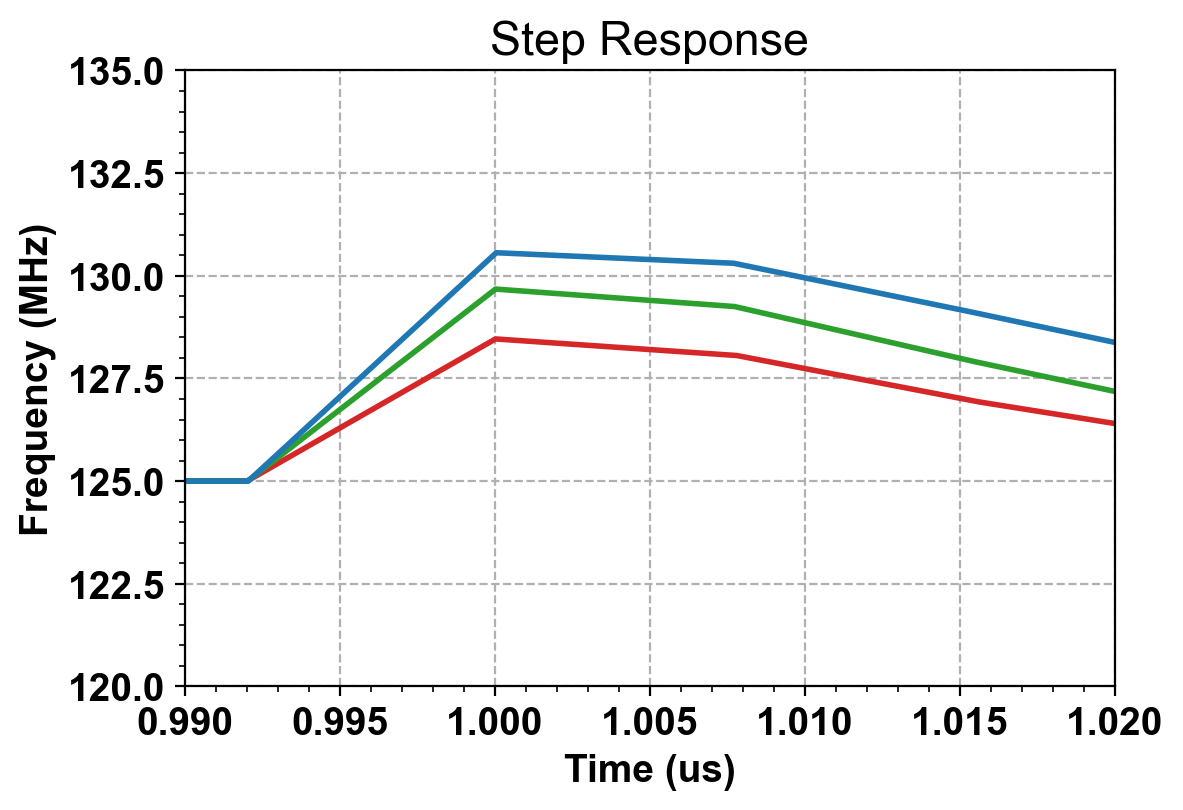

SS settling time after rising edge: 0.304 us (absolute time: 1.304 us)
TT settling time after rising edge: 0.288 us (absolute time: 1.288 us)
FF settling time after rising edge: 0.248 us (absolute time: 1.248 us)


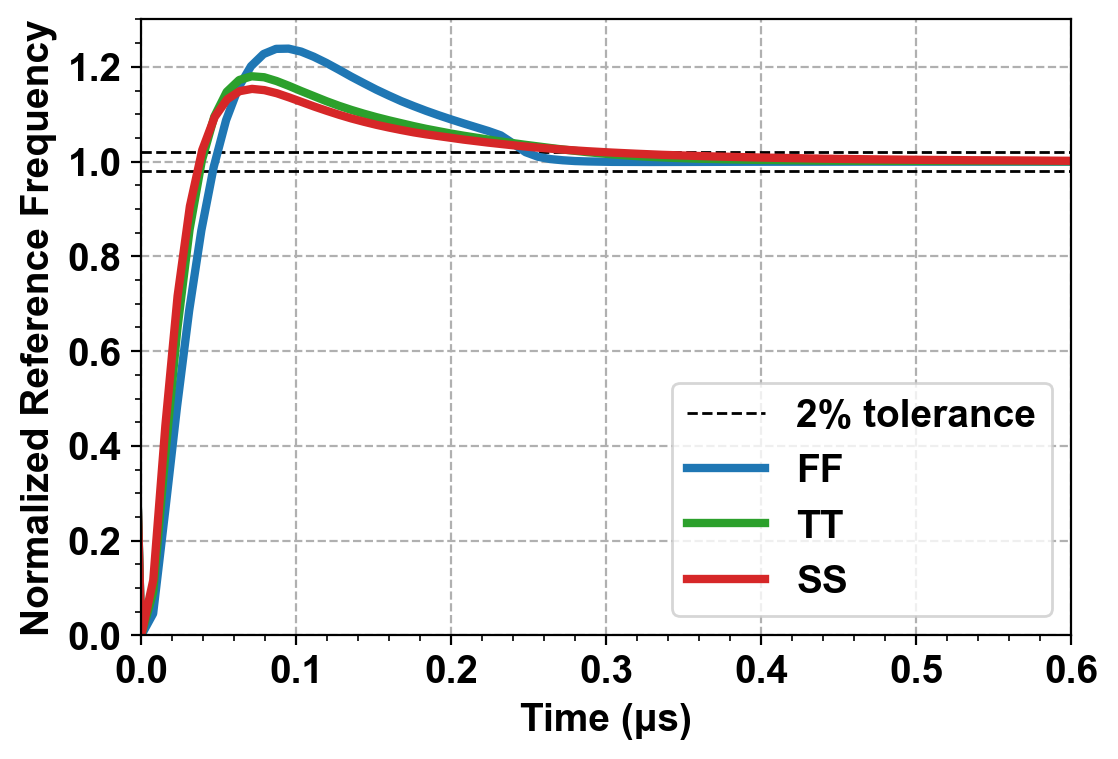

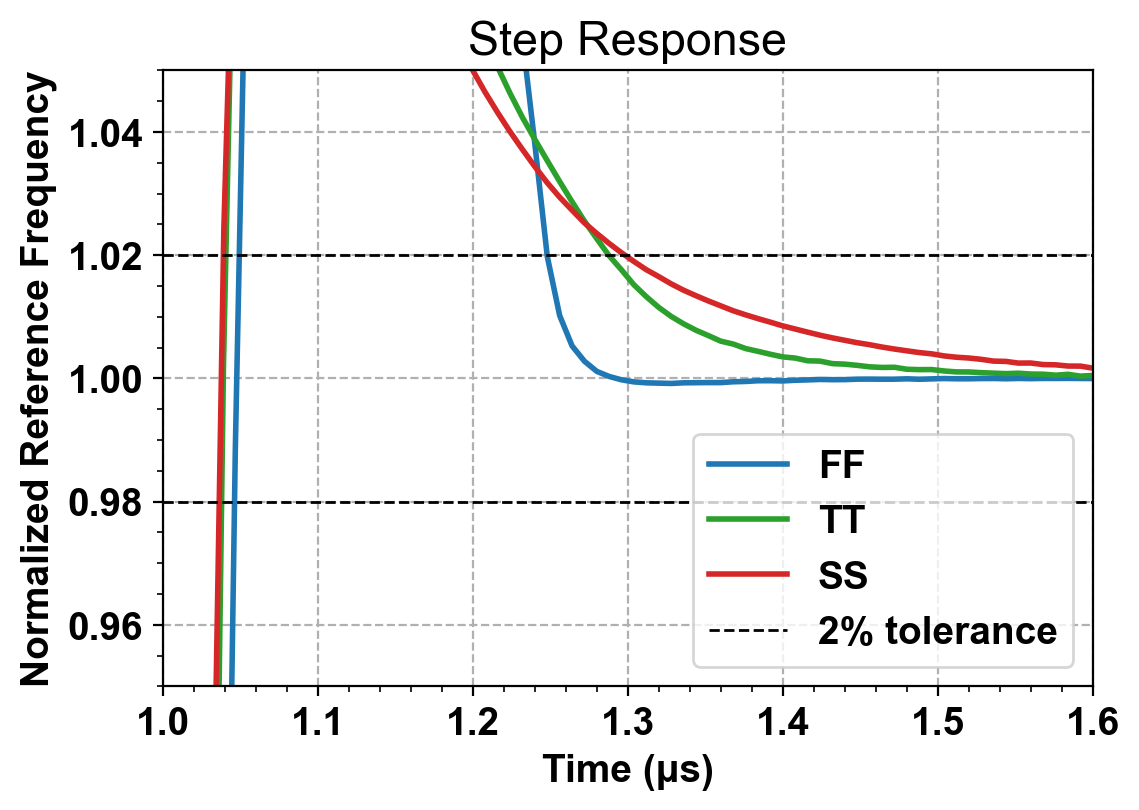

In [108]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

# Plot Step response Frequency output
plt.figure(figsize=(6, 4), dpi=200)
plt.minorticks_on()
plt.plot(time_div_ss * 1e6, freq_div_ss*1e-6, color='tab:red', linewidth=2)
plt.plot(time_div_tt * 1e6, freq_div_tt*1e-6, color='tab:green', linewidth=2)
plt.plot(time_div_ff * 1e6, freq_div_ff*1e-6, color='tab:blue', linewidth=2)
plt.title('Step Response')
plt.xlabel('Time (us)', fontweight='bold')
plt.ylabel('Frequency (MHz)', fontweight='bold')
plt.grid(True, linestyle='--', which='major')
plt.xlim([0.99, 1.02])  # Focus on settling time region
plt.ylim([120, 135])  # Focus on settling time region
plt.show()

index_ss = np.flatnonzero(time_div_ss > 1.00e-6)
index_ss = index_ss[0] if index_ss.size else None

index_tt = np.flatnonzero(time_div_tt > 1.00e-6)
index_tt = index_tt[0] if index_tt.size else None

index_ff = np.flatnonzero(time_div_ff > 1.00e-6)
index_ff = index_ff[0] if index_ff.size else None

#print(num2eng(index_tt,4))
#print(num2eng(time_ss[index_tt]))
#print(num2eng(freq_ss[index_tt],4))

freq_div_min_ss = freq_div_ss[index_ss]
freq_div_target_ss = 125e6 - freq_div_min_ss
norm_div_freq_ss =(freq_div_ss - freq_div_min_ss) / freq_div_target_ss

freq_div_min_tt = freq_div_tt[index_tt]
freq_div_target_tt = 125e6 - freq_div_min_tt
norm_div_freq_tt =(freq_div_tt - freq_div_min_tt) / freq_div_target_tt

freq_div_min_ff = freq_div_ff[index_ff]
freq_div_target_ff = 125e6 - freq_div_min_ff
norm_div_freq_ff =(freq_div_ff - freq_div_min_ff) / freq_div_target_ff

def settling_time_2pct(time, response, step_time=1e-6, end_time=None):
    in_pulse = time >= step_time
    if end_time is not None:
        in_pulse &= time < end_time
    pulse_time = time[in_pulse]
    pulse_response = response[in_pulse]
    if not pulse_time.size:
        return None
    in_tolerance = np.isfinite(pulse_response) & (np.abs(pulse_response - 1.0) <= 0.02)
    remains_in_tolerance = np.logical_and.accumulate(in_tolerance[::-1])[::-1]
    candidates = np.flatnonzero(remains_in_tolerance)
    if not candidates.size:
        return None
    return pulse_time[candidates[0]] - step_time

settling_div_ss = settling_time_2pct(
    time_div_ss, norm_div_freq_ss, end_time=2e-6
)
settling_div_tt = settling_time_2pct(
    time_div_tt, norm_div_freq_tt, end_time=2e-6
)
settling_div_ff = settling_time_2pct(
    time_div_ff, norm_div_freq_ff, end_time=2e-6
)

for label, settling_time in (
    ('SS', settling_div_ss),
    ('TT', settling_div_tt),
    ('FF', settling_div_ff),
):
    if settling_time is None:
        print(f'{label}: no settling within the pulse interval')
    else:
        absolute_time = 1e-6 + settling_time
        print(
            f'{label} settling time after rising edge: {settling_time * 1e6:.3f} us '
            f'(absolute time: {absolute_time * 1e6:.3f} us)'
        )

# Plot Step response Normalized Frequency output
plt.figure(figsize=(6, 4), dpi=200)
plt.minorticks_on()
plt.axhline(0.98, color='black', linestyle='--', linewidth=1, label='2% tolerance')
plt.axhline(1.02, color='black', linestyle='--', linewidth=1, label='_nolegend_')
plt.plot((time_div_ff * 1e6)-1, norm_div_freq_ff, color='tab:blue', linewidth=3, label='FF')
plt.plot((time_div_tt * 1e6)-1, norm_div_freq_tt, color='tab:green', linewidth=3, label='TT')
plt.plot((time_div_ss * 1e6)-1, norm_div_freq_ss, color='tab:red', linewidth=3, label='SS')
#plt.title('Step Response')
plt.xlabel('Time (μs)', fontweight='bold')
plt.ylabel('Normalized Reference Frequency', fontweight='bold')
plt.grid(True, linestyle='--', which='major')
plt.xlim([0, 0.6])  # Focus on settling time region
plt.ylim([0, 1.3])  # Focus on settling time region
plt.legend()
plt.show()

# Plot Step response Normalized Frequency output
plt.figure(figsize=(6, 4), dpi=200)
plt.minorticks_on()
plt.plot(time_div_ff * 1e6, norm_div_freq_ff, color='tab:blue', linewidth=2, label='FF')
plt.plot(time_div_tt * 1e6, norm_div_freq_tt, color='tab:green', linewidth=2, label='TT')
plt.plot(time_div_ss * 1e6, norm_div_freq_ss, color='tab:red', linewidth=2, label='SS')
plt.axhline(0.98, color='black', linestyle='--', linewidth=1, label='2% tolerance')
plt.axhline(1.02, color='black', linestyle='--', linewidth=1, label='_nolegend_')
plt.title('Step Response')
plt.xlabel('Time (μs)', fontweight='bold')
plt.ylabel('Normalized Reference Frequency', fontweight='bold')
plt.grid(True, linestyle='--', which='major')
plt.xlim([1.0, 1.6])  # Show the complete pulse and falling edge
plt.ylim([0.95, 1.05])  # Focus on the 2% tolerance band
plt.legend()
plt.show()